In [192]:
import numpy as np
import pandas as pd

df = pd.read_csv(r'C:\Users\jaskew\Documents\project_repository\notebooks\observationEventForecasting\DataPreprocessing\FullIndicatorMatrix.csv')
df['date'] = pd.to_datetime(df['date'])
df.sort_values(by=['indicator', 'date'], inplace=True)

# Limit to the last 100 unique dates
latest_dates = df['date'].drop_duplicates().sort_values().tail(100)
df = df[df['date'].isin(latest_dates)]

df[df['indicator'] == '146.71.50.198']

,API_UserName,date,indicator,observations,dayofweek,is_weekend,day,month,seen
102424,818860012482918321,2025-02-17,146.71.50.198,0,0,False,17,2,0
102672,818860012482918321,2025-02-18,146.71.50.198,0,1,False,18,2,0
102920,818860012482918321,2025-02-19,146.71.50.198,0,2,False,19,2,0
103168,818860012482918321,2025-02-20,146.71.50.198,0,3,False,20,2,0
103416,818860012482918321,2025-02-21,146.71.50.198,0,4,False,21,2,0
...,...,...,...,...,...,...,...,...,...
125984,818860012482918321,2025-05-23,146.71.50.198,0,4,False,23,5,0
126232,818860012482918321,2025-05-24,146.71.50.198,0,5,True,24,5,0
126480,818860012482918321,2025-05-25,146.71.50.198,0,6,True,25,5,0
126728,818860012482918321,2025-05-26,146.71.50.198,0,0,False,26,5,0


In [193]:
# Function to extract features per indicator
def extract_time_series_features(group):
    series = group['seen'].values
    dates = group['date'].values

    indices = np.where(series == 1)[0]
    if len(indices) == 0:
        return pd.Series({
            'last_seen': len(series),
            'freq_7': 0,
            'freq_30': 0,
            'avg_gap': len(series),
            'burstiness': 0,
            'label_7': 0,
            'label_14': 0,
            'label_30': 0
        })

    last_seen = len(series) - 1 - indices[-1] # Number of days since the IP was last seen. Recent = low value. Captures recency.
    freq_7 = np.sum(series[-7:]) # Count of days seen in the last 7 days. Measures short-term activity.
    freq_30 = np.sum(series[-30:]) # Count of days seen in the last 30 days. Measures medium-term activity.
    gaps = np.diff(indices)
    avg_gap = np.mean(gaps) if len(gaps) > 0 else len(series) # Average time (in days) between two consecutive sightings. Shows periodicity.
    burstiness = (np.std(gaps) - avg_gap) / (np.std(gaps) + avg_gap) if len(gaps) > 1 else 0 # Measures how irregular or volatile the sightings are. Based on standard deviation of gaps: Ranges from -1 (very regular) to +1 (very bursty).
    label_7 = 1 if np.any(series[-7:]) else 0
    label_14 = 1 if np.any(series[-14:]) else 0
    label_30 = 1 if np.any(series[-30:]) else 0

    return pd.Series({
        'last_seen': last_seen,
        'freq_7': freq_7,
        'freq_30': freq_30,
        'avg_gap': avg_gap,
        'burstiness': burstiness,
        'label_7': label_7,
        'label_14': label_14,
        'label_30': label_30
    })

# Apply to each indicator group
features_df = df.groupby('indicator').apply(extract_time_series_features).reset_index()

C:\Users\jaskew\AppData\Local\Temp\ipykernel_22212\1570248052.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  features_df = df.groupby('indicator').apply(extract_time_series_features).reset_index()


In [194]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from lifelines import WeibullAFTFitter
from scipy.stats import expon
import numpy as np

# Copy features into a separate DataFrame for modeling
df_pred = features_df.copy()

# Define features and labels
X = df_pred[['last_seen', 'freq_7', 'freq_30', 'avg_gap', 'burstiness']]
y_7 = df_pred['label_7']
y_14 = df_pred['label_14']
y_30 = df_pred['label_30']

# Helper functions
def train_predict(model_cls, X, y):
    if len(np.unique(y)) < 2:
        return np.full(len(y), np.nan)
    model = Pipeline([('scaler', StandardScaler()), ('clf', model_cls())])
    model.fit(X, y)
    return model.predict_proba(X)[:, 1]

def train_gbt(X, y):
    if len(np.unique(y)) < 2:
        return np.full(len(y), np.nan)
    model = GradientBoostingClassifier()
    model.fit(X, y)
    return model.predict_proba(X)[:, 1]

# Logistic Regression Predictions
df_pred['logistic_7'] = train_predict(LogisticRegression, X, y_7)
df_pred['logistic_14'] = train_predict(LogisticRegression, X, y_14)
df_pred['logistic_30'] = train_predict(LogisticRegression, X, y_30)

# Gradient Boosted Tree Predictions
df_pred['gbt_7'] = train_gbt(X, y_7)
df_pred['gbt_14'] = train_gbt(X, y_14)
df_pred['gbt_30'] = train_gbt(X, y_30)

# Exponential Model (Poisson-based) P(\text{seen in } t \text{ days}) = 1 - e^{-λt}, \quad \text{where } λ = \frac{\text{freq_30}}{30}
rate = (df_pred['freq_30'] / 30).clip(lower=1e-6)
df_pred['exp_7'] = 1 - np.exp(-rate * 7)
df_pred['exp_14'] = 1 - np.exp(-rate * 14)
df_pred['exp_30'] = 1 - np.exp(-rate * 30)

# Weibull AFT Model A survival model that predicts time until next sighting.
aft_df = X.copy()
aft_df['duration'] = df_pred['avg_gap']
aft_df['event'] = y_7

aft = WeibullAFTFitter()
aft.fit(aft_df, duration_col='duration', event_col='event')

# Predict survival function at 1, 7, 14, 30 days
surv_func = aft.predict_survival_function(aft_df, times=[1, 7, 14, 30])
df_pred['weibull_today'] = 1 - surv_func.loc[1].values
df_pred['weibull_7'] = 1 - surv_func.loc[7].values
df_pred['weibull_14'] = 1 - surv_func.loc[14].values
df_pred['weibull_30'] = 1 - surv_func.loc[30].values

# Today's forecast
df_pred['exp_today'] = 1 - np.exp(-rate * 1)
df_pred['logistic_today'] = safe_train_predict(LogisticRegression, X, y_7)
df_pred['gbt_today'] = train_gbt(X, y_7)

# Merge in actual "seen" value for today's date
latest_date = df['date'].max()
today_seen = df[df['date'] == latest_date][['indicator', 'seen']].rename(columns={'seen': 'seen_today'})
df_pred = df_pred.merge(today_seen, on='indicator', how='left')

# Final output
output = df_pred[[
    'indicator', 'seen_today', 'last_seen', 'freq_7', 'freq_30', 'avg_gap', 'burstiness',
    'exp_today', 'exp_7', 'exp_14', 'exp_30',
    'weibull_today', 'weibull_7', 'weibull_14', 'weibull_30',
    'logistic_today', 'logistic_7', 'logistic_14', 'logistic_30',
    'gbt_today', 'gbt_7', 'gbt_14', 'gbt_30'
]]

display(output)


,indicator,seen_today,last_seen,freq_7,freq_30,avg_gap,burstiness,exp_today,exp_7,exp_14,...,weibull_14,weibull_30,logistic_today,logistic_7,logistic_14,logistic_30,gbt_today,gbt_7,gbt_14,gbt_30
0,102.129.153.158,0,6.0,1.0,1.0,37.500000,-0.388889,3.278390e-02,0.208110,0.372911,...,1.145179e-01,6.966056e-01,0.850298,0.850298,0.941891,0.981488,0.999974,0.999974,0.999978,0.999984
1,102.129.153.43,0,11.0,0.0,1.0,36.500000,-0.403846,3.278390e-02,0.208110,0.372911,...,3.187223e-02,2.721433e-01,0.093552,0.093552,0.618092,0.949615,0.000017,0.000017,0.999978,0.999984
2,102.129.153.71,0,4.0,1.0,1.0,18.200000,-0.181514,3.278390e-02,0.208110,0.372911,...,6.892446e-01,9.999895e-01,0.861869,0.861869,0.952876,0.989344,0.999974,0.999974,0.999978,0.999984
3,102.165.16.161,0,47.0,0.0,0.0,6.000000,-0.381966,9.999995e-07,0.000007,0.000014,...,1.859060e-04,1.821634e-03,0.008437,0.008437,0.014067,0.211250,0.000017,0.000017,0.000022,0.000028
4,103.147.185.248,0,5.0,1.0,1.0,100.000000,0.000000,3.278390e-02,0.208110,0.372911,...,1.778648e-03,1.730670e-02,0.910108,0.910108,0.948200,0.976644,0.999974,0.999974,0.999978,0.999984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243,international.standardbank.com/,0,100.0,0.0,0.0,100.000000,0.000000,9.999995e-07,0.000007,0.000014,...,3.008593e-12,2.950429e-11,0.000636,0.000636,0.000016,0.000263,0.000017,0.000017,0.000022,0.000028
244,pub.marq.com/,0,13.0,0.0,1.0,9.600000,0.122880,3.278390e-02,0.208110,0.372911,...,3.289175e-01,9.799902e-01,0.087593,0.087593,0.536315,0.964691,0.000017,0.000017,0.999978,0.999984
245,realinvestmentadvice.com/,0,8.0,0.0,1.0,8.000000,0.021684,3.278390e-02,0.208110,0.372911,...,6.674197e-01,9.999795e-01,0.110829,0.110829,0.689969,0.979108,0.000017,0.000017,0.999978,0.999984
246,www.emergencylighting.com/,0,6.0,1.0,1.0,100.000000,0.000000,3.278390e-02,0.208110,0.372911,...,1.446149e-03,1.409199e-02,0.904900,0.904900,0.941501,0.973794,0.999974,0.999974,0.999978,0.999984


In [195]:
output.drop(columns=['indicator'])

,seen_today,last_seen,freq_7,freq_30,avg_gap,burstiness,exp_today,exp_7,exp_14,exp_30,...,weibull_14,weibull_30,logistic_today,logistic_7,logistic_14,logistic_30,gbt_today,gbt_7,gbt_14,gbt_30
0,0,6.0,1.0,1.0,37.500000,-0.388889,3.278390e-02,0.208110,0.372911,0.632121,...,1.145179e-01,6.966056e-01,0.850298,0.850298,0.941891,0.981488,0.999974,0.999974,0.999978,0.999984
1,0,11.0,0.0,1.0,36.500000,-0.403846,3.278390e-02,0.208110,0.372911,0.632121,...,3.187223e-02,2.721433e-01,0.093552,0.093552,0.618092,0.949615,0.000017,0.000017,0.999978,0.999984
2,0,4.0,1.0,1.0,18.200000,-0.181514,3.278390e-02,0.208110,0.372911,0.632121,...,6.892446e-01,9.999895e-01,0.861869,0.861869,0.952876,0.989344,0.999974,0.999974,0.999978,0.999984
3,0,47.0,0.0,0.0,6.000000,-0.381966,9.999995e-07,0.000007,0.000014,0.000030,...,1.859060e-04,1.821634e-03,0.008437,0.008437,0.014067,0.211250,0.000017,0.000017,0.000022,0.000028
4,0,5.0,1.0,1.0,100.000000,0.000000,3.278390e-02,0.208110,0.372911,0.632121,...,1.778648e-03,1.730670e-02,0.910108,0.910108,0.948200,0.976644,0.999974,0.999974,0.999978,0.999984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243,0,100.0,0.0,0.0,100.000000,0.000000,9.999995e-07,0.000007,0.000014,0.000030,...,3.008593e-12,2.950429e-11,0.000636,0.000636,0.000016,0.000263,0.000017,0.000017,0.000022,0.000028
244,0,13.0,0.0,1.0,9.600000,0.122880,3.278390e-02,0.208110,0.372911,0.632121,...,3.289175e-01,9.799902e-01,0.087593,0.087593,0.536315,0.964691,0.000017,0.000017,0.999978,0.999984
245,0,8.0,0.0,1.0,8.000000,0.021684,3.278390e-02,0.208110,0.372911,0.632121,...,6.674197e-01,9.999795e-01,0.110829,0.110829,0.689969,0.979108,0.000017,0.000017,0.999978,0.999984
246,0,6.0,1.0,1.0,100.000000,0.000000,3.278390e-02,0.208110,0.372911,0.632121,...,1.446149e-03,1.409199e-02,0.904900,0.904900,0.941501,0.973794,0.999974,0.999974,0.999978,0.999984


In [196]:
output[output['indicator'] == '102.129.153.158']

,indicator,seen_today,last_seen,freq_7,freq_30,avg_gap,burstiness,exp_today,exp_7,exp_14,...,weibull_14,weibull_30,logistic_today,logistic_7,logistic_14,logistic_30,gbt_today,gbt_7,gbt_14,gbt_30
0,102.129.153.158,0,6.0,1.0,1.0,37.5,-0.388889,0.032784,0.20811,0.372911,...,0.114518,0.696606,0.850298,0.850298,0.941891,0.981488,0.999974,0.999974,0.999978,0.999984


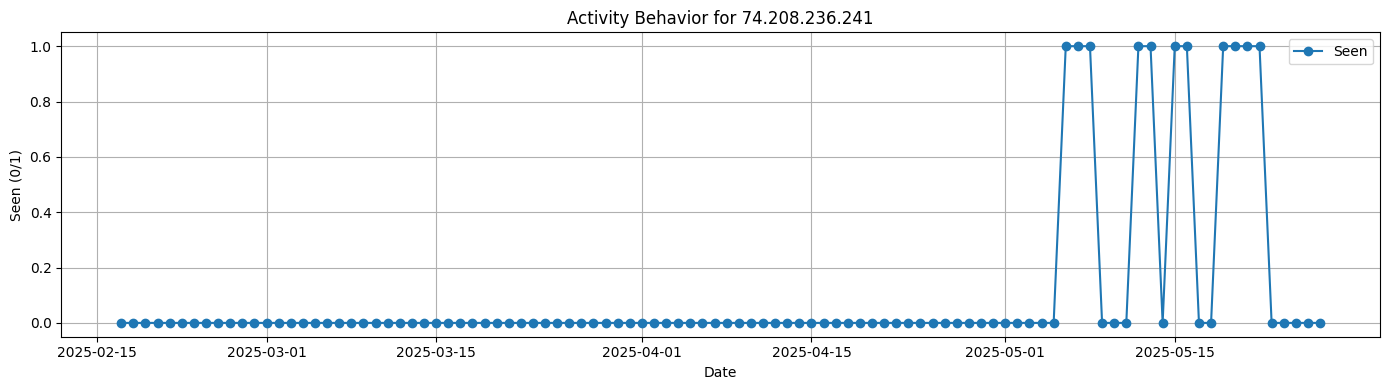

In [197]:
import matplotlib.pyplot as plt

indicator_id = '74.208.236.241'
df_plot = df[df['indicator'] == indicator_id].sort_values('date')

plt.figure(figsize=(14, 4))
plt.plot(df_plot['date'], df_plot['seen'], marker='o', linestyle='-', label='Seen')
plt.title(f'Activity Behavior for {indicator_id}')
plt.xlabel('Date')
plt.ylabel('Seen (0/1)')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

In [198]:
output[output['indicator'] == '113.96.236.11']

,indicator,seen_today,last_seen,freq_7,freq_30,avg_gap,burstiness,exp_today,exp_7,exp_14,...,weibull_14,weibull_30,logistic_today,logistic_7,logistic_14,logistic_30,gbt_today,gbt_7,gbt_14,gbt_30
18,113.96.236.11,0,68.0,0.0,0.0,1.75,-0.357033,9.999995e-07,0.000007,0.000014,...,0.000003,0.000034,0.002273,0.002273,0.00095,0.023232,0.000017,0.000017,0.000022,0.000028


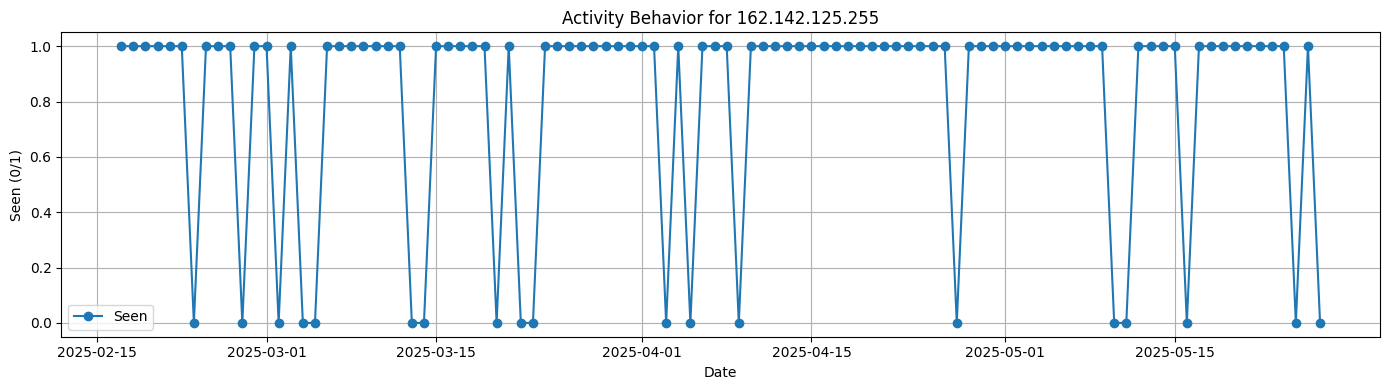

In [199]:
indicator_id = '162.142.125.255'
df_plot = df[df['indicator'] == indicator_id].sort_values('date')

plt.figure(figsize=(14, 4))
plt.plot(df_plot['date'], df_plot['seen'], marker='o', linestyle='-', label='Seen')
plt.title(f'Activity Behavior for {indicator_id}')
plt.xlabel('Date')
plt.ylabel('Seen (0/1)')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

In [200]:
df[(df['seen'] ==0) & (df['date'] == pd.Timestamp('2025-05-21'))]

,API_UserName,date,indicator,observations,dayofweek,is_weekend,day,month,seen
125632,818860012482918321,2025-05-21,102.129.153.43,0,2,False,21,5,0
125500,818860012482918321,2025-05-21,102.129.153.71,0,2,False,21,5,0
125650,818860012482918321,2025-05-21,102.165.16.161,0,2,False,21,5,0
125717,818860012482918321,2025-05-21,103.147.185.248,0,2,False,21,5,0
125734,818860012482918321,2025-05-21,103.156.92.159,0,2,False,21,5,0
...,...,...,...,...,...,...,...,...,...
125709,818860012482918321,2025-05-21,93.123.109.231,0,2,False,21,5,0
125643,818860012482918321,2025-05-21,hcmiu.edu.vn/,0,2,False,21,5,0
125599,818860012482918321,2025-05-21,international.standardbank.com/,0,2,False,21,5,0
125677,818860012482918321,2025-05-21,pub.marq.com/,0,2,False,21,5,0


In [304]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import expon
import numpy as np

#  Define features and labels ---
features = ['last_seen', 'freq_7', 'freq_30', 'avg_gap', 'burstiness']
X = output[features]

#  Rule-Based Binary Labels Using last_seen ---
output['rule_today'] = output['last_seen'].apply(lambda x: 1 if x == 0 else 0)
output['rule_7d'] = output['last_seen'].apply(lambda x: 1 if x <= 6 else 0)
output['rule_14d'] = output['last_seen'].apply(lambda x: 1 if x <= 13 else 0)
output['rule_30d'] = output['last_seen'].apply(lambda x: 1 if x <= 29 else 0)

y_today = output['rule_today']
y_7 = output['rule_7d']
y_14 = output['rule_14d']
y_30 = output['rule_30d']

#  Logistic Regression Model ---
def train_logistic_model(X, y):
    if len(np.unique(y)) < 2:
        return np.full(len(y), np.nan)
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression())
    ])
    model.fit(X, y)
    return model.predict_proba(X)[:, 1]

output['prob_today'] = train_logistic_model(X, y_today)
output['prob_7d'] = train_logistic_model(X, y_7)
output['prob_14d'] = train_logistic_model(X, y_14)
output['prob_30d'] = train_logistic_model(X, y_30)

#  Ensemble Probabilities ---
output['ensemble_7d'] = (
    0.3 * output['prob_7d'].astype(float) +
    0.25 * output['gbt_7'] +
    0.25 * output['weibull_7'] +
    0.3 * output['exp_7']
)

output['ensemble_14d'] = (
    0.3 * output['prob_14d'].astype(float) +
    0.25 * output['gbt_14'] +
    0.25* output['weibull_14'] +
    0.3 * output['exp_14']
)

output['ensemble_30d'] = (
    0.3 * output['prob_30d'].astype(float) +
    0.25 * output['gbt_14'] +
    0.25 * output['weibull_30'] +
    0.3 * output['exp_30']
)

#  Confidence Tags ---
def classify_window(prob, freq_7, high_thresh, label):
    if prob >= high_thresh and freq_7 >= 2:
        return f"{label}: Highly likely"
    elif prob >= 0.07 and freq_7 >= 1:
        return f"{label}: Possibly active"
    else:
        return f"{label}: Low confidence"

# Compute confidence tags using raw probabilities (not formatted as strings)
output['confidence_today'] = output.apply(
    lambda row: classify_window(
        row['prob_today'],
        row['freq_7'], 0.6, 'Today'
    ), axis=1
)

output['confidence_7d'] = output.apply(
    lambda row: classify_window(
        row['ensemble_7d'],
        row['freq_7'], 0.6, '7-Day'
    ), axis=1
)

output['confidence_14d'] = output.apply(
    lambda row: classify_window(
        row['ensemble_14d'],
        row['freq_7'], 0.6, '14-Day'
    ), axis=1
)

output['confidence_30d'] = output.apply(
    lambda row: classify_window(
        row['ensemble_30d'],
        row['freq_7'], 0.6, '30-Day'
    ), axis=1
)

#  Format Percentages ---
for col in ['prob_7d', 'prob_14d', 'prob_30d', 'ensemble_7d', 'ensemble_14d', 'ensemble_30d']:
    output[col] = np.clip(output[col].astype(float) * 100, 0, 100).round(2).astype(str) + '%'

#  Format Today prob ---
output['prob_today'] = np.clip(output['prob_today'].astype(float) * 100, 0, 100).round(2).astype(str) + '%'

#  Final Output ---
production_output = output[[
    'indicator', 'seen_today', 'freq_7', 'freq_30',
    'prob_today', 'confidence_today',
    'ensemble_7d', 'confidence_7d',
    'ensemble_14d', 'confidence_14d',
    'ensemble_30d', 'confidence_30d'
]].copy()

# --- Rename for display ---
production_output.rename(columns={
    'indicator': 'Indicator',
    'seen_today': 'Observed Today',
    'freq_7': 'Frequency (7d)',
    'freq_30': 'Frequency (30d)',
    'prob_today': 'Probability: Today',
    'confidence_today': 'Confidence: Today',
    'ensemble_7d': 'Probability: 7-Day',
    'confidence_7d': 'Confidence: 7-Day',
    'ensemble_14d': 'Probability: 14-Day',
    'confidence_14d': 'Confidence: 14-Day',
    'ensemble_30d': 'Probability: 30-Day',
    'confidence_30d': 'Confidence: 30-Day'
}, inplace=True)

display(production_output)



,Indicator,Observed Today,Frequency (7d),Frequency (30d),Probability: Today,Confidence: Today,Probability: 7-Day,Confidence: 7-Day,Probability: 14-Day,Confidence: 14-Day,Probability: 30-Day,Confidence: 30-Day
0,102.129.153.158,0,1.0,1.0,1.03%,Today: Low confidence,57.13%,7-Day: Possibly active,67.31%,14-Day: Possibly active,90.82%,30-Day: Possibly active
1,102.129.153.43,0,0.0,1.0,0.48%,Today: Low confidence,9.15%,7-Day: Low confidence,55.53%,14-Day: Low confidence,79.26%,30-Day: Low confidence
2,102.129.153.71,0,1.0,1.0,0.96%,Today: Low confidence,60.51%,7-Day: Possibly active,82.0%,14-Day: Possibly active,98.64%,30-Day: Possibly active
3,102.165.16.161,0,0.0,0.0,0.32%,Today: Low confidence,0.25%,7-Day: Low confidence,0.43%,14-Day: Low confidence,6.38%,30-Day: Low confidence
4,103.147.185.248,0,1.0,1.0,0.41%,Today: Low confidence,58.55%,7-Day: Possibly active,64.68%,14-Day: Possibly active,73.7%,30-Day: Possibly active
...,...,...,...,...,...,...,...,...,...,...,...,...
243,international.standardbank.com/,0,0.0,0.0,0.04%,Today: Low confidence,0.02%,7-Day: Low confidence,0.0%,14-Day: Low confidence,0.01%,30-Day: Low confidence
244,pub.marq.com/,0,0.0,1.0,0.3%,Today: Low confidence,10.09%,7-Day: Low confidence,60.5%,14-Day: Low confidence,97.4%,30-Day: Low confidence
245,realinvestmentadvice.com/,0,0.0,1.0,0.38%,Today: Low confidence,12.79%,7-Day: Low confidence,73.57%,14-Day: Low confidence,98.34%,30-Day: Low confidence
246,www.emergencylighting.com/,0,1.0,1.0,0.4%,Today: Low confidence,58.39%,7-Day: Possibly active,64.47%,14-Day: Possibly active,73.53%,30-Day: Possibly active


In [220]:
production_output['Indicator']

0                      102.129.153.158
1                       102.129.153.43
2                       102.129.153.71
3                       102.165.16.161
4                      103.147.185.248
                    ...               
243    international.standardbank.com/
244                      pub.marq.com/
245          realinvestmentadvice.com/
246         www.emergencylighting.com/
247                   www.shorturl.at/
Name: Indicator, Length: 248, dtype: object

In [305]:
production_analysis_indicators = production_output[production_output['Observed Today'] == 1]
production_analysis_indicators

,Indicator,Observed Today,Frequency (7d),Frequency (30d),Probability: Today,Confidence: Today,Probability: 7-Day,Confidence: 7-Day,Probability: 14-Day,Confidence: 14-Day,Probability: 30-Day,Confidence: 30-Day
14,104.21.48.1,1,7.0,30.0,64.86%,Today: Highly likely,100.0%,7-Day: Highly likely,100.0%,14-Day: Highly likely,100.0%,30-Day: Highly likely
72,172.240.108.68,1,5.0,26.0,25.77%,Today: Possibly active,100.0%,7-Day: Highly likely,100.0%,14-Day: Highly likely,100.0%,30-Day: Highly likely
77,176.65.148.250,1,5.0,5.0,35.45%,Today: Possibly active,99.67%,7-Day: Highly likely,100.0%,14-Day: Highly likely,100.0%,30-Day: Highly likely
109,204.76.203.212,1,2.0,2.0,1.84%,Today: Low confidence,87.58%,7-Day: Highly likely,98.04%,14-Day: Highly likely,100.0%,30-Day: Highly likely
241,geo.netsupportsoftware.com/location/loca.asp,1,3.0,11.0,4.3%,Today: Low confidence,100.0%,7-Day: Highly likely,100.0%,14-Day: Highly likely,100.0%,30-Day: Highly likely


In [306]:
import os
import pandas as pd
from datetime import datetime, timedelta

# Base file path with placeholder for date
base_path = r"Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d{date}.csv"
#base_path = r"C:\Users\jaskew\Documents\project_repository\data\raw\ObservationDataFiles\htoc_opdiv_obs_d{date}.csv"
date_format = "%Y%m%d"

def get_file_paths(base_path, days=90):
    """ Generate file paths for the last `days` days using list comprehension. """
    today = datetime.utcnow()
    dates_to_pull = [(today - timedelta(days=i)).strftime(date_format) for i in range(days)]
    
    # Construct file paths
    file_paths = [base_path.format(date=dt) for dt in dates_to_pull]
    
    # Filter for existing files
    existing_files = [file_path for file_path in file_paths if os.path.exists(file_path)]
    
    if not existing_files:
        print("No files found for the specified date range.")
    else:
        print(f"Files to be loaded: {existing_files}")
    
    return existing_files

def load_observed_data(file_paths):
    """ Load and concatenate observed data from multiple files. """
    data_frames = []

    for file_path in file_paths:
        try:
            df = pd.read_csv(file_path)
            data_frames.append(df)
        except Exception as e:
            print(f"Error reading file {file_path}: {e}")
    
    # Concatenate data
    if data_frames:
        observed_data_df = pd.concat(data_frames, ignore_index=True)
        print(f"Loaded data from {len(data_frames)} files.")
    else:
        observed_data_df = pd.DataFrame()

    return observed_data_df

# Example Usage:
# Fetch file paths for the last 3 days
file_paths = get_file_paths(base_path, days=90)

# Load observed data
observed_data_df = load_observed_data(file_paths)



Files to be loaded: ['Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250527.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250526.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250525.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250524.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250523.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250522.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250521.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250520.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250519.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250518.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250517.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250516.csv', 'Z:/HTOC/Data_Analytics/Data/Op

In [325]:
# For each indicator in production_analysis_indicators, pull obs_date and OpDiv from observed_data_df

# Get the list of indicators
indicators = production_analysis_indicators['Indicator'].unique()

# Filter observed_data_df for those indicators and select relevant columns
indicator_obs = observed_data_df[observed_data_df['indicator'].isin(indicators)][['indicator', 'obs_date', 'OpDiv']]

display(indicator_obs)

,indicator,obs_date,OpDiv
39,204.76.203.212,2025-05-27,NIH
40,204.76.203.212,2025-05-27,HRSA
41,204.76.203.212,2025-05-27,DHA
42,204.76.203.212,2025-05-27,VA
43,204.76.203.212,2025-05-27,IHS
...,...,...,...
44917,104.21.48.1,2025-02-27,CMS
45002,172.240.108.68,2025-02-27,CDC
45003,172.240.108.68,2025-02-27,HHS
45004,172.240.108.68,2025-02-27,HRSA


In [326]:
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd

# Ensure obs_date is datetime and column names are consistent
if 'Indicator' in indicator_obs.columns:
    indicator_obs = indicator_obs.rename(columns={'Indicator': 'indicator'})

indicator_obs['obs_date'] = pd.to_datetime(indicator_obs['obs_date'], errors='coerce')

# Get unique indicators
indicators = indicator_obs['indicator'].unique()

for indicator in indicators:
    group = indicator_obs[indicator_obs['indicator'] == indicator]
    opdivs = group['OpDiv'].unique()
    opdiv_to_idx = {opdiv: i for i, opdiv in enumerate(opdivs)}

    fig = go.Figure()
    for opdiv in opdivs:
        opdiv_group = group[group['OpDiv'] == opdiv]
        if not opdiv_group.empty:
            y_val = opdiv_to_idx[opdiv]
            jitter = np.random.uniform(-0.2, 0.2, size=len(opdiv_group))
            fig.add_trace(go.Scatter(
                x=opdiv_group['obs_date'],
                y=[y_val + j for j in jitter],
                mode='markers+text',
                marker=dict(size=12, color=px.colors.qualitative.Plotly[y_val % 10], line=dict(width=1, color='black')),
                name=opdiv,
                text=opdiv_group['OpDiv'],
                textposition='top center',
                hovertemplate='OpDiv: %{text}<br>Date: %{x|%Y-%m-%d}<extra></extra>'
            ))

    fig.update_layout(
        title=f'All Observation Dates for {indicator}',
        yaxis=dict(
            tickmode='array',
            tickvals=list(opdiv_to_idx.values()),
            ticktext=list(opdiv_to_idx.keys()),
            title='OpDiv'
        ),
        xaxis_title='Observation Date',
        height=80 + 60 * len(opdivs),
        legend_title='OpDiv',
        margin=dict(l=40, r=40, t=40, b=40)
    )
    fig.show()
